# Datasets — What They Are, Why We Use Them, and How We Preprocess Them

This notebook walks through every data source used in the internship in logical order:

| Step | Section |
|------|---------|
| 1 | **BOAMP** — raw JSON from the API |
| 2 | **DECP** — raw Parquet file |
| 3 | **Preprocessing pipeline** — what we clean and why |
| 4 | **Clean datasets** — the outputs we actually model on |
| 5 | **Renewal linking** — building the survival target variable |
| 6 | **Source comparison** — which source is better for which field |

> **Goal:** by the end of this notebook you should know *what each dataset contains*, *why it exists*, and *what transformations turn raw data into something usable*.

In [1]:
import json, warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 80)

ROOT      = Path('..') 
RAW_BOAMP = ROOT / 'data' / 'raw'  / 'boamp_sample'
RAW_DECP  = ROOT / 'data' / 'raw'  / 'decp' / 'decp.parquet'
PROCESSED = ROOT / 'data' / 'processed'

sns.set_theme(style='whitegrid', palette='muted')
print('Ready.')

Ready.


---
## 1 — BOAMP (Bulletin Officiel des Annonces des Marchés Publics)

### What is it?

BOAMP is the **official French journal for public procurement notices**. Every time a public body (city, hospital, region, state agency…) launches a procurement procedure or awards a contract, it must publish a notice in BOAMP. 

The API returns one JSON record per notice. There are two main types of notices:

| Notice type (`nature`) | Meaning |
|------------------------|---------|
| `APPEL_OFFRE` | Call for tenders — the public body *announces* it wants to buy something |
| `ATTRIBUTION` | Award notice — the public body *announces who won* and for how much |

### Why do we use it?

- It is the **only source** covering the full 2015–2024 period for all French public contracts.
- It has the richest **free-text contract descriptions** (`objet`) → useful for NLP classification later.
- Award notices contain `annonce_lie` (a link back to the original call), which is our main hint for **renewal linking** (building the survival target variable).
- It distinguishes *calls* from *awards* — the event structure survival analysis needs.

### Scope we collected

We fetched **500 notices** from 2015 to 2024, filtered to:
- **Pays de la Loire** departments (44, 49, 53, 72, 85)
- **Digital / IT contracts** (CPV codes starting with 48, 72, 32, 35…)

In [2]:
# Load one raw API page to see what a BOAMP JSON record looks like
sample_page = sorted(RAW_BOAMP.glob('*.json'))[0]
with open(sample_page) as f:
    page = json.load(f)

print(f'File   : {sample_page.name}')
print(f'Records in this page: {len(page["results"])}  |  total_count in API: {page["total_count"]:,}')
print()

# Show the top-level fields of one record
record = page['results'][0]
print('Top-level fields in a raw BOAMP record:')
for k, v in record.items():
    if k != 'donnees':
        print(f'  {k:<35} {str(v)[:70]}')

File   : boamp_2015_p1.json
Records in this page: 100  |  total_count in API: 2,599

Top-level fields in a raw BOAMP record:
  idweb                               15-30334
  id                                  15_30334
  contractfolderid                    None
  objet                               transport collectif à titre principal scolaire par véhicules légers de
  filename                            BOAMP-J-AO_2015_061003
  famille                             JOUE
  code_departement                    ['53']
  code_departement_prestation         53
  famille_libelle                     Marchés européens
  dateparution                        2015-03-02
  datefindiffusion                    2015-04-13
  datelimitereponse                   2015-04-13T16:30:00+00:00
  nomacheteur                         Conseil Général de la Mayenne
  titulaire                           None
  perimetre                           DIRECTIVE-18
  type_procedure                      OUVERT
  soustype_pro

The record has two layers:

- **Top-level fields** — easy to read (id, dates, buyer name, department, CPV…)
- **`donnees`** — a nested JSON *inside* the record that contains the full notice body (CPV codes, amounts, lots, participation conditions…)

Parsing `donnees` is necessary to extract CPV codes, amounts and durations.

In [3]:
# Show the sub-structure of `donnees` for the same record
donnees = record.get('donnees', {})
if isinstance(donnees, str):
    donnees = json.loads(donnees)

print('Keys inside `donnees`:')
for k in donnees.keys():
    print(f'  {k}')

Keys inside `donnees`:
  IDENTITE
  TYPE_POUVOIR_ADJUDICATEUR
  ACTIVITE_PRINCIPALE
  OBJET
  PROCEDURE
  PUBLICATION_ANTERIEURE
  CONDITION_DELAI
  CONDITION_RELATIVE_MARCHE
  CONDITION_PARTICIPATION
  CONDITION_ADMINISTRATIVE
  RENSEIGNEMENTS_COMPLEMENTAIRES


In [4]:
# Load ALL collected BOAMP pages into a single DataFrame (top-level fields only)
records = []
for f in sorted(RAW_BOAMP.glob('*.json')):
    with open(f) as fh:
        page_data = json.load(fh)
    records.extend(page_data['results'])

raw_boamp = pd.DataFrame([{k: v for k, v in r.items() if k != 'donnees'} for r in records])

print(f'Shape : {raw_boamp.shape}  ({raw_boamp.shape[0]} notices × {raw_boamp.shape[1]} top-level fields)')
print(f'Years : {raw_boamp["dateparution"].str[:4].min()}  →  {raw_boamp["dateparution"].str[:4].max()}')
print()
print('Notice types (nature):')
print(raw_boamp['nature'].value_counts().to_string())

Shape : (11700, 40)  (11700 notices × 40 top-level fields)
Years : 2015  →  2024

Notice types (nature):
nature
APPEL_OFFRE           7549
ATTRIBUTION           3807
RECTIFICATIF           304
PRE-INFORMATION         17
MODIFICATION            13
INTENTION_CONCLURE       6
AUTRE                    2
PERIODIQUE               2


In [5]:
# Show a small readable sample
cols_to_show = ['idweb', 'dateparution', 'nomacheteur', 'code_departement',
                'nature', 'type_marche', 'objet']
raw_boamp[cols_to_show].head(5)

,idweb,dateparution,nomacheteur,code_departement,nature,type_marche,objet
0,15-30334,2015-03-02,Conseil Général de la Mayenne,[53],APPEL_OFFRE,[SERVICES],transport collectif à titre principal scolaire par véhicules légers de capac...
1,15-30947,2015-03-02,SMICTOM de la Vallée de l'Authion,[49],APPEL_OFFRE,[SERVICES],"Acquisition de systèmes d'identification embarqués, location des solutions l..."
2,15-31011,2015-03-02,CHU d'Angers,[49],APPEL_OFFRE,[SERVICES],prestations de surveillance et de gardiennage au profit du CHU à Angers
3,15-31464,2015-03-02,Sdis de la Mayenne,[53],APPEL_OFFRE,[FOURNITURES],fourniture de petits materiels d'incendie et de secours et pieces detachees ...
4,15-30979,2015-03-02,CH LE MANS,[72],APPEL_OFFRE,None,mission de maîtrise d'oeuvre pour la construction d'un bâtiment hébergeant d...


### The eForms reform (2024): two completely different formats

In 2024 the EU mandated a new XML standard for public procurement notices called **eForms**.  
BOAMP adopted it immediately, so the same API returns **two incompatible formats** depending on the year:

| | Legacy (2015–2023) | eForms (2024–) |
|---|---|---|
| Format signal | `source_schema = "Boamp_v230.xsd"` | `contractfolderid` is a UUID |
| `donnees` structure | French keys: `IDENTITE`, `OBJET`, `PROCEDURE`… | Single key `EFORMS` → UBL/XML-style JSON |
| SIRET | **Absent** | Inside `cbc:CompanyID` |
| CPV code | `donnees → OBJET → CPV → CODE` | `donnees → EFORMS → … → cac:Item → cbc:Description` |
| Award date | Real date | **Always `2000-01-01`** (placeholder — must be excluded) |

The cell below loads one real record of each type and prints the key structural differences side by side.

In [6]:
import textwrap

# ── helpers ───────────────────────────────────────────────────────────────────
def load_donnees(record):
    d = record.get('donnees', {})
    return json.loads(d) if isinstance(d, str) else d

def find_nested(obj, key, max_depth=15):
    """Return the first value found for `key` anywhere in a nested dict/list."""
    if max_depth == 0:
        return None
    if isinstance(obj, dict):
        if key in obj:
            return obj[key]
        for v in obj.values():
            result = find_nested(v, key, max_depth - 1)
            if result is not None:
                return result
    elif isinstance(obj, list):
        for item in obj:
            result = find_nested(item, key, max_depth - 1)
            if result is not None:
                return result
    return None

def get_text(val):
    """Unwrap a {'#text': '...'} dict or return the value directly."""
    if isinstance(val, dict):
        return val.get('#text', str(val))
    return str(val) if val is not None else 'not found'

# ── pick one legacy record (2015) ─────────────────────────────────────────────
with open(RAW_BOAMP / 'boamp_2015_p1.json') as f:
    r_legacy = json.load(f)['results'][0]
d_legacy = load_donnees(r_legacy)

# ── pick one eForms record (2024, identified by contractfolderid UUID) ────────
r_eforms = None
for p in sorted(RAW_BOAMP.glob('boamp_2024*.json')):
    with open(p) as f:
        for r in json.load(f)['results']:
            if r.get('contractfolderid'):
                r_eforms = r
                break
    if r_eforms:
        break
d_eforms = load_donnees(r_eforms)

# ── extract fields ─────────────────────────────────────────────────────────────

# Format signal
fmt_legacy = r_legacy.get('source_schema', '(absent)')          # e.g. "Boamp_v230.xsd"
fmt_eforms = r_eforms.get('source_schema') or '(absent)'        # absent in eForms

folder_legacy = r_legacy.get('contractfolderid') or '(absent)'
folder_eforms = str(r_eforms.get('contractfolderid'))[:36]

# donnees top-level keys
keys_legacy = list(d_legacy.keys())
keys_eforms = list(d_eforms.keys())   # ['EFORMS']

# SIRET
# Legacy: not present anywhere → ABSENT
# eForms: cac:PartyLegalEntity → cbc:CompanyID  (11 levels deep in UBL tree)
siret_legacy = 'ABSENT (field did not exist)'
siret_eforms = get_text(find_nested(d_eforms, 'cbc:CompanyID')) or 'not found'

# CPV
# Legacy: donnees → OBJET → CPV → PRINCIPAL
# eForms: cbc:ItemClassificationCode with @listName="cpv" → #text
cpv_legacy = d_legacy.get('OBJET', {}).get('CPV', {}).get('PRINCIPAL', 'not found')
raw_cpv = find_nested(d_eforms, 'cbc:ItemClassificationCode')
cpv_eforms = get_text(raw_cpv) if raw_cpv else 'not found'

# Award / issue date
# Legacy: donnees → ... → DATE_ATTRIBUTION  (only on award notices)
# eForms: ContractNotice → cbc:IssueDate  (notice publication date)
date_legacy = find_nested(d_legacy, 'DATE_ATTRIBUTION') or 'not found (AAPC notice has none)'
date_eforms = get_text(find_nested(d_eforms, 'cbc:IssueDate')) or 'not found'

# ── print side-by-side table ──────────────────────────────────────────────────
rows = [
    ('Field',                  'Legacy  (2015)',                      'eForms  (2024)'),
    ('─' * 24,                 '─' * 52,                              '─' * 52),
    ('Notice ID',              r_legacy.get('idweb', ''),             r_eforms.get('idweb', '')),
    ('Buyer name',             r_legacy.get('nomacheteur', ''),       r_eforms.get('nomacheteur', '')),
    ('source_schema',          fmt_legacy,                            fmt_eforms),
    ('contractfolderid',       folder_legacy,                         folder_eforms),
    ('donnees top-level keys', '\n'.join(keys_legacy),                '\n'.join(keys_eforms)),
    ('SIRET  (cbc:CompanyID)', siret_legacy,                          siret_eforms),
    ('Main CPV code',          str(cpv_legacy),                       cpv_eforms),
    ('Notice/issue date',      str(date_legacy),                      date_eforms),
]

col_w = [26, 50, 52]
sep   = '  │  '
for row in rows:
    lines_per_col = [str(row[i]).split('\n') for i in range(3)]
    n_lines = max(len(l) for l in lines_per_col)
    for j in range(n_lines):
        print(
            (lines_per_col[0][j] if j < len(lines_per_col[0]) else '').ljust(col_w[0]) + sep +
            (lines_per_col[1][j] if j < len(lines_per_col[1]) else '').ljust(col_w[1]) + sep +
            (lines_per_col[2][j] if j < len(lines_per_col[2]) else '')
        )

Field                       │  Legacy  (2015)                                      │  eForms  (2024)
────────────────────────    │  ────────────────────────────────────────────────────  │  ────────────────────────────────────────────────────
Notice ID                   │  15-30334                                            │  24-33909
Buyer name                  │  Conseil Général de la Mayenne                       │  Commune Mauges sur Loire
source_schema               │  Boamp_v230.xsd                                      │  3.2.5
contractfolderid            │  (absent)                                            │  c1eb17e3-7ab5-4041-a0e2-588c16bde1b2
donnees top-level keys      │  IDENTITE                                            │  EFORMS
                            │  TYPE_POUVOIR_ADJUDICATEUR                           │  
                            │  ACTIVITE_PRINCIPALE                                 │  
                            │  OBJET                                  

---
## 2 — DECP (Données Essentielles de la Commande Publique)

### What is it?

DECP is a **mandatory open-data publication** introduced by French regulation in 2018. Any public authority that awards a contract above €25 000 must publish a structured record on data.gouv.fr within two months of signing. 

The data is consolidated by the AIFE (the French government's finance IT agency) and available as a Parquet file. Unlike BOAMP — which records *announcements* — DECP records the **final, signed contract**.

### Why do we use it?

DECP fills the gaps that BOAMP leaves:

| Field | BOAMP coverage | DECP coverage |
|-------|---------------|---------------|
| Buyer SIRET | ~3% | **100%** |
| Amount (EUR) | ~44% | **95%** |
| Contract duration | ~34% | **99%** |
| Notification date | absent | **100%** |

The notification date (`dateNotification`) is especially important: it is the **starting point** for survival analysis (we measure how long from signing to renewal).

### Scope

The full DECP file covers all of France. We filter it to the same scope as BOAMP: Pays de la Loire, digital CPV codes, 2015–2024.

In [7]:
raw_decp = pd.read_parquet(RAW_DECP)

print(f'Shape (full France, all sectors) : {raw_decp.shape}')
print(f'Columns : {list(raw_decp.columns)}')

Shape (full France, all sectors) : (3075779, 58)
Columns : ['uid', 'id', 'nature', 'acheteur_id', 'acheteur_nom', 'titulaire_id', 'titulaire_typeIdentifiant', 'titulaire_nom', 'objet', 'montant', 'type', 'codeCPV', 'procedure', 'techniques', 'dureeMois', 'dureeRestanteMois', 'offresRecues', 'dateNotification', 'datePublicationDonnees', 'formePrix', 'typesPrix', 'attributionAvance', 'tauxAvance', 'marcheInnovant', 'modalitesExecution', 'considerationsSociales', 'considerationsEnvironnementales', 'ccag', 'sousTraitanceDeclaree', 'typeGroupementOperateurs', 'origineUE', 'origineFrance', 'lieuExecution_code', 'lieuExecution_typeCode', 'idAccordCadre', 'titulaire_distance', 'acheteur_categorie', 'acheteur_commune_code', 'acheteur_commune_nom', 'acheteur_departement_code', 'acheteur_departement_nom', 'acheteur_region_code', 'acheteur_region_nom', 'acheteur_latitude', 'acheteur_longitude', 'titulaire_categorie', 'titulaire_commune_code', 'titulaire_commune_nom', 'titulaire_departement_code', 

In [8]:
# Show a readable sample of key fields
decp_cols = ['id', 'dateNotification', 'acheteur_nom', 'acheteur_departement_code',
             'nature', 'codeCPV', 'montant', 'dureeMois', 'titulaire_nom', 'objet']
raw_decp[decp_cols].head(5)

,id,dateNotification,acheteur_nom,acheteur_departement_code,nature,codeCPV,montant,dureeMois,titulaire_nom,objet
0,1300214414,2026-06-10,DIRECTION GENERALE DE L'ADMINISTRATION PENITENTIAIRE,75,Marché,34144700,277017.02,12.0,SONOMA,Le marché spécifique a pour objet l’acquisition de véhicules d’occasion de t...
1,1100071040,2026-06-10,DIRECTION INTERDEPARTEMENTALE DES ROUTES OUEST,35,Marché,45233140,718009.00,6.0,SWARCO FRANCE,"Fourniture, pose, raccordement et mise en service d’un panneau à messages va..."
2,1513699809,2026-06-10,DIRECTION INTERDEPARTEMENTALE DES ROUTES CENTRE-EST,69,Marché,45233224,910716.25,10.0,COLAS FRANCE (ETABLISSEMENT LOIRE HAUTE-LOIRE),Travaux complémentaires au renforcement du mur Terrenoire ouest (PR) sur la ...
3,1100071010,2026-06-10,None,None,Marché,71000000,561550.00,58.0,GAU,NLL - LA CAVALERIE (12) - Camp du Larzac - 13 DBLE - Création d’un pôle spor...
4,1100044751,2026-06-10,DIRECTION REGIONALE DE L'ENVIRONNEMENT DE L'AMENAGEMENT ET DU LOGEMENT HAUTS...,59,Marché,71311220,3125730.00,108.0,SETEC INTERNATIONAL,Mission de maîtrise d’oeuvre relative à l’aménagement à 2x2 voies de la Rout...


In [ ]:
# Coverage of key fields in the RAW file (before any filtering)
key_fields = ['acheteur_id', 'acheteur_nom', 'codeCPV', 'montant',
              'dureeMois', 'dateNotification', 'titulaire_nom', 'offresRecues']
coverage = (raw_decp[key_fields].notna().mean() * 100).round(1).rename('fill %')
print('Field completeness in raw DECP (full France):')
print(coverage.to_string())

Field completeness in raw DECP (full France):
acheteur_id         100.0
acheteur_nom         99.4
codeCPV             100.0
montant              98.4
dureeMois            99.1
dateNotification     99.0
titulaire_nom        95.6
offresRecues         39.3


: 

---
## 3 — Preprocessing Pipeline

Raw data cannot be used directly for modeling. This section explains **every transformation** applied, in order.

```
Raw BOAMP JSON  ──►  Step 1: Filter scope  ──►  Step 2: Flatten donnees
                                                        │
Raw DECP Parquet ──► Step 1: Filter scope               ▼
                                             Step 3: Normalize buyer keys
                                             Step 4: Flag/clean amounts
                                             Step 5: Flag/clean durations
                                             Step 6: Tag taxonomy category
                                                        │
                                                        ▼
                                             boamp_clean.csv  /  decp_clean.csv
```

### Step 1 — Filter to scope

We apply three filters to both sources:

| Filter | Rule | Why |
|--------|------|-----|
| Geography | Department in {44, 49, 53, 72, 85} | Pays de la Loire = Gigalis's primary territory |
| Sector | CPV code starts with 48, 72, 32, 35 (+ subcategories) | Digital IT contracts only |
| Recency | Year between 2015 and 2024 | 10 years = at least one full renewal cycle for 4-year contracts |

For DECP we also keep only `donneesActuelles = True` (latest version of each contract, not historic amendments).

In [ ]:
# Reproduce the DECP filtering funnel step by step to see how many rows each filter removes
PdL_depts = {'44', '49', '53', '72', '85'}
DIGITAL_DIVS = {'48', '72', '32', '35'}

n_raw = len(raw_decp)

# 1. Current version only
df1 = raw_decp[raw_decp['donneesActuelles'] == True]

# 2. PdL departments
df2 = df1[df1['acheteur_departement_code'].astype(str).isin(PdL_depts)]

# 3. Digital CPV
df3 = df2[df2['codeCPV'].astype(str).str[:2].isin(DIGITAL_DIVS)]

# 4. Year range 2015-2024
df4 = df3[df3['dateNotification'].astype(str).str[:4].between('2015', '2024')]

print('DECP filtering funnel:')
print(f'  Raw (all France, all sectors)    : {n_raw:>8,}')
print(f'  After current-version filter     : {len(df1):>8,}')
print(f'  After PdL department filter      : {len(df2):>8,}')
print(f'  After digital CPV filter         : {len(df3):>8,}')
print(f'  After 2015-2024 year filter      : {len(df4):>8,}  ← our working corpus')

### Step 2 — Flatten the BOAMP `donnees` field

BOAMP stores CPV codes, amounts, and structured details inside a nested JSON blob called `donnees`. We parse it to extract:
- `cpv_principal` — the primary CPV code
- `cpv_all` — all CPV codes listed
- `amount_eur` — contract value in euros
- `duration_months` — declared duration
- `date_attribution` — award date
- `buyer_siret` — SIRET identifier (only available on recent eForms notices)

This step is unique to BOAMP; DECP is already flat.

In [ ]:
# Compare raw top-level columns vs the cleaned flat CSV
raw_cols  = set(raw_boamp.columns)
clean_csv = pd.read_csv(PROCESSED / 'boamp_clean.csv', nrows=0)
clean_cols = set(clean_csv.columns)

added = sorted(clean_cols - raw_cols)
print('Fields ADDED by parsing donnees and cleaning:')
for c in added:
    print(f'  + {c}')

Fields ADDED by parsing donnees and cleaning:
  + amount_clean
  + amount_eur
  + amount_raw
  + buyer_cp
  + buyer_key
  + buyer_siret
  + buyer_ville
  + category_id
  + category_label
  + cpv_all
  + cpv_class4
  + cpv_clean
  + cpv_div2
  + cpv_principal
  + date_attribution
  + date_publication_anterieure
  + donnees_format
  + duration_clean
  + duration_months
  + duration_raw_boamp
  + duration_source_field
  + flag_amount_ceiling
  + flag_amount_tiny
  + flag_amount_zero
  + flag_duration_suspect


### Step 3 — Buyer normalization

The same public body can appear under many names across records and sources.  
Example: *"SDIS 44"*, *"Service Départemental d'Incendie et de Secours de la Loire-Atlantique"*, *"SDIS de la Loire-Atlantique"* all refer to the same organization.

We create a **canonical buyer key** (`buyer_key`) using this priority:

1. **SIRET** (14-digit tax identifier) — unique and stable — used when available
2. **Normalized name** — lowercase, accents removed, legal-form suffixes stripped ("Commune de", "SARL"…) — fallback for BOAMP legacy notices

This key is what connects a buyer's contracts across time (needed to detect renewal patterns).

In [ ]:
boamp_clean = pd.read_csv(PROCESSED / 'boamp_clean.csv', low_memory=False)
decp_clean  = pd.read_csv(PROCESSED / 'decp_clean.csv',  low_memory=False)

# Buyer normalization stats
boamp_siret_pct = boamp_clean['buyer_siret'].notna().mean() * 100
decp_siret_pct  = decp_clean['acheteur_id'].notna().mean()  * 100

print('Buyer SIRET availability after normalization:')
print(f'  BOAMP : {boamp_siret_pct:.1f}%  (legacy notices have no SIRET — name-key is used)')
print(f'  DECP  : {decp_siret_pct:.1f}%  (mandatory in DECP format)')
print()

# Show a few buyer_key examples from each source
print('Examples of buyer_key values (BOAMP):')
print(boamp_clean['buyer_key'].head(6).to_string(index=False))
print()
print('Examples of buyer_key values (DECP — always SIRET-anchored):')
print(decp_clean['buyer_key'].head(6).to_string(index=False))

Buyer SIRET availability after normalization:
  BOAMP : 8.0%  (legacy notices have no SIRET — name-key is used)
  DECP  : 100.0%  (mandatory in DECP format)

Examples of buyer_key values (BOAMP):
NAME:smictom de la vallee de l authion
                     NAME:de la sarthe
                    NAME:de la mayenne
                        NAME:de nantes
                             NAME:reze
                       NAME:bouguenais

Examples of buyer_key values (DECP — always SIRET-anchored):
SIRET:21440162200011
SIRET:24440055200026
SIRET:20003329800015
SIRET:24490001500011
SIRET:24490001500011
SIRET:22440002800011


### Step 4 — Amount cleaning

Contract amounts in raw data contain several types of bad values. We **flag** them rather than delete them (so the original is always preserved):

| Flag | Rule | Meaning |
|------|------|---------|
| `flag_amount_zero` | value == 0 | Encoding artefact |
| `flag_amount_tiny` | 0 < value < 1 000 € | Implausible for an IT contract |
| `flag_amount_ceiling` | value ≥ 10 000 000 € | Likely a framework-agreement ceiling, not an actual price |

When any flag is `True`, `amount_clean` is set to `NaN`. Otherwise it equals the raw value.

In [ ]:
for name, df, raw_col in [('BOAMP', boamp_clean, 'amount_raw'), ('DECP', decp_clean, 'amount_raw')]:
    n = len(df)
    n_zero    = df['flag_amount_zero'].sum()
    n_tiny    = df['flag_amount_tiny'].sum()
    n_ceil    = df['flag_amount_ceiling'].sum()
    n_clean   = df['amount_clean'].notna().sum()
    print(f'{name}  (n={n})')
    print(f'  Flagged zero            : {n_zero}')
    print(f'  Flagged tiny (<1k EUR)  : {n_tiny}')
    print(f'  Flagged ceiling (≥10M)  : {n_ceil}')
    print(f'  amount_clean fill rate  : {n_clean/n*100:.1f}%')
    print()

BOAMP  (n=500)
  Flagged zero            : 0
  Flagged tiny (<1k EUR)  : 3
  Flagged ceiling (≥10M)  : 5
  amount_clean fill rate  : 43.0%

DECP  (n=3039)
  Flagged zero            : 31
  Flagged tiny (<1k EUR)  : 20
  Flagged ceiling (≥10M)  : 23
  amount_clean fill rate  : 93.1%



### Step 5 — Duration cleaning

Declared duration (`duration_months` in BOAMP, `dureeMois` in DECP) is the key input for survival analysis.  
We flag values **outside [1, 120] months** as suspect and set `duration_clean` to `NaN` for those rows.

- Below 1 month → almost certainly an encoding error
- Above 120 months (10 years) → unusual; more likely a data entry mistake

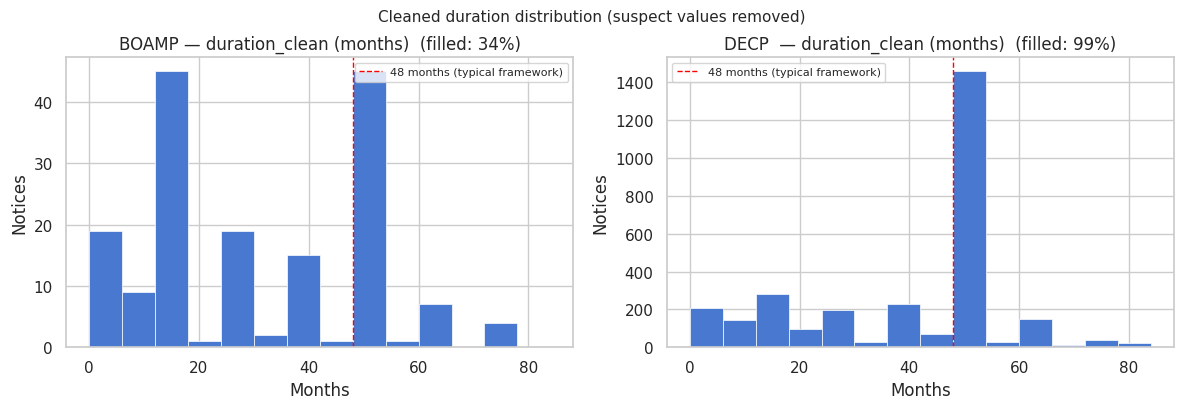

Duration fill rate after cleaning:
  BOAMP: 34.2% usable  (1 suspect flags set to NaN)
  DECP: 99.2% usable  (6 suspect flags set to NaN)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df, col) in zip(axes, [
        ('BOAMP — duration_clean (months)', boamp_clean, 'duration_clean'),
        ('DECP  — duration_clean (months)', decp_clean,  'duration_clean')]):
    d = df[col].dropna()
    d_trim = d[d <= 84]  # trim at 7 years for readability
    ax.hist(d_trim, bins=range(0, 85, 6), edgecolor='white', linewidth=0.5)
    ax.set_title(name)
    ax.set_xlabel('Months')
    ax.set_ylabel('Notices')
    ax.axvline(48, color='red', linestyle='--', linewidth=1, label='48 months (typical framework)')
    ax.legend(fontsize=8)
    fill = d.notna().sum() / len(df) * 100
    ax.set_title(f'{name}  (filled: {fill:.0f}%)')

plt.tight_layout()
plt.suptitle('Cleaned duration distribution (suspect values removed)', y=1.02, fontsize=11)
plt.show()

print('Duration fill rate after cleaning:')
for name, df in [('BOAMP', boamp_clean), ('DECP', decp_clean)]:
    r = df['duration_clean'].notna().mean() * 100
    s = df['flag_duration_suspect'].sum()
    print(f'  {name}: {r:.1f}% usable  ({s} suspect flags set to NaN)')

### Step 6 — Taxonomy tagging

CPV codes alone are hard to reason about (there are 9 000 of them). We map them to **10 human-readable technology categories** that matter for Gigalis's purchasing strategy.

The tagging logic:
1. Match the first 2–5 digits of the CPV code against the category's CPV prefixes.
2. If no CPV match, fall back to keyword search in the contract `objet` text.
3. If nothing matches → `CAT_UNKNOWN`.

In [ ]:
# Show the taxonomy reference table
taxonomy = pd.read_csv(PROCESSED / 'taxonomy.csv')
taxonomy[['category_id', 'category_label', 'cpv_divisions']].rename(
    columns={'category_id': 'ID', 'category_label': 'Category', 'cpv_divisions': 'CPV divisions'})

,ID,Category,CPV divisions
0,CAT01,Software & Applications,48
1,CAT02,IT Services & Consulting,72
2,CAT03,Cybersecurity,35
3,CAT04,Telecom & Networks,32
4,CAT05,Cloud & Infrastructure,48800
5,CAT06,IT Hardware & Equipment,30
6,CAT07,Digital Workplace & Collaboration,48500
7,CAT08,Data & AI,72300
8,CAT09,GIS & Mapping,72320
9,CAT10,IT Maintenance & Support,50300


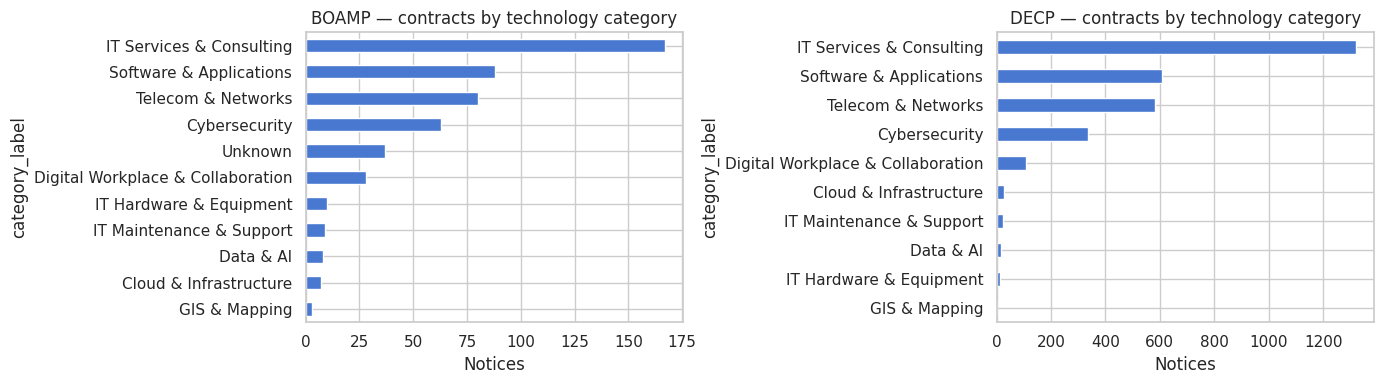

In [ ]:
# Contract count by category in each source
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, [('BOAMP', boamp_clean), ('DECP', decp_clean)]):
    counts = df['category_label'].value_counts()
    counts.plot(kind='barh', ax=ax)
    ax.set_title(f'{name} — contracts by technology category')
    ax.set_xlabel('Notices')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 4 — Clean Datasets

After all preprocessing steps we have two ready-to-use flat CSVs.

| File | Source | Rows | Key added columns |
|------|--------|------|-------------------|
| `boamp_clean.csv` | BOAMP API | ~500 | `amount_clean`, `duration_clean`, `buyer_key`, `category_label`, all flags |
| `decp_clean.csv` | DECP Parquet | ~3 039 | `amount_clean`, `duration_clean`, `buyer_key`, `category_label`, all flags |

In [ ]:
print('boamp_clean shape :', boamp_clean.shape)
print('decp_clean  shape :', decp_clean.shape)

# Key columns to show
boamp_show = ['idweb', 'dateparution', 'nomacheteur', 'nature', 'category_label',
              'amount_clean', 'duration_clean', 'buyer_key']
decp_show  = ['id', 'dateNotification', 'acheteur_nom', 'nature', 'category_label',
              'amount_clean', 'duration_clean', 'buyer_key']

print('\n--- BOAMP clean (first 5 rows) ---')
display(boamp_clean[boamp_show].head(5))

print('\n--- DECP clean (first 5 rows) ---')
display(decp_clean[decp_show].head(5))

boamp_clean shape : (500, 44)
decp_clean  shape : (3039, 36)

--- BOAMP clean (first 5 rows) ---


,idweb,dateparution,nomacheteur,nature,category_label,amount_clean,duration_clean,buyer_key
0,15-30947,2015-03-02,SMICTOM de la Vallée de l'Authion,APPEL_OFFRE,Software & Applications,150000.0,12.0,NAME:smictom de la vallee de l authion
1,15-31397,2015-03-03,SDIS de la Sarthe,ATTRIBUTION,Software & Applications,NaN,NaN,NAME:de la sarthe
2,15-31464,2015-03-02,Sdis de la Mayenne,APPEL_OFFRE,Unknown,NaN,36.0,NAME:de la mayenne
3,15-32296,2015-03-04,CHU de Nantes,ATTRIBUTION,Software & Applications,230957.2,NaN,NAME:de nantes
4,15-31513,2015-03-02,Ville de Rezé,APPEL_OFFRE,Unknown,NaN,48.0,NAME:reze



--- DECP clean (first 5 rows) ---


,id,dateNotification,acheteur_nom,nature,category_label,amount_clean,duration_clean,buyer_key
0,2024K-P0rgdsDS00,2024-12-31,COMMUNE DE SAINT-HERBLAIN (MAIRIE),Marché,IT Services & Consulting,140000.0,48.0,SIRET:21440162200011
1,25-1065514,2024-12-31,COMMUNAUTE DE COMMUNES DU PAYS D'ANCENIS,Marché,Software & Applications,174400.0,48.0,SIRET:24440055200026
2,2024M02124000000,2024-12-27,COMMUNAUTE DE COMMUNES DES COEVRONS,Marché,IT Services & Consulting,80000.0,48.0,SIRET:20003329800015
3,2024A24129P,2024-12-26,COMMUNAUTE URBAINE ANGERS LOIRE METROPOLE,Marché,IT Services & Consulting,220999.0,60.0,SIRET:24490001500011
4,2024A24130P,2024-12-26,COMMUNAUTE URBAINE ANGERS LOIRE METROPOLE,Marché,IT Services & Consulting,220999.0,60.0,SIRET:24490001500011


In [ ]:
# Overall completeness of the clean datasets
def completeness_summary(df, key_cols, source_name):
    s = (df[key_cols].notna().mean() * 100).round(1)
    s.name = source_name
    return s

key_cols = ['amount_clean', 'duration_clean', 'buyer_key', 'category_label']

summary = pd.concat([
    completeness_summary(boamp_clean, key_cols, 'BOAMP fill %'),
    completeness_summary(decp_clean,  key_cols, 'DECP fill %'),
], axis=1)

print('Completeness of the four most critical modelling columns:')
display(summary)

Completeness of the four most critical modelling columns:


,BOAMP fill %,DECP fill %
amount_clean,43.0,93.1
duration_clean,34.2,99.2
buyer_key,100.0,100.0
category_label,100.0,100.0


---
## 5 — Renewal Linking (building the survival target variable)

### Why do we need this?

Survival analysis asks: *how long does a contract last before it is renewed?*  
Neither BOAMP nor DECP provides a direct `renewal_of` field. We must **reconstruct the renewal relationship** algorithmically.

### How does the linking work?

For each contract A, we look for a later contract B from the **same buyer** that:

1. Has the **same CPV division** (same technology segment)
2. Appears **later in time** (`dateNotification` of B > `dateNotification` of A)
3. Falls within a **time window** around A's declared duration (± 6 months)
4. Has an **object similarity ≥ 0.30** (token Jaccard on the `objet` field)

If a match B is found → A is a **renewal event** (observed duration = time A→B).  
If no match is found → A is **censored** (contract still active or unobserved).

Censoring is handled by survival analysis — contracts with no observed renewal are not discarded, they contribute partial information.

In [ ]:
links = pd.read_csv(PROCESSED / 'decp_renewal_links.csv')
links['is_censored'] = links['is_censored'].astype(bool)

n_total   = len(decp_clean)
n_events  = (~links['is_censored']).sum()
n_censored = links['is_censored'].sum()
link_rate = n_events / n_total * 100

print(f'Total contracts in corpus         : {n_total:>6}')
print(f'  Linked renewal found (events)   : {n_events:>6}  ({link_rate:.1f}%)')
print(f'  No renewal found (censored)     : {n_censored:>6}  ({100-link_rate:.1f}%)')
print()

obs_all    = links['observed_duration_months']
obs_events = links.loc[~links['is_censored'], 'observed_duration_months']
print(f'Median observed duration (all)     : {obs_all.median():.1f} months')
print(f'Median observed duration (events)  : {obs_events.median():.1f} months')

Total contracts in corpus         :   3039
  Linked renewal found (events)   :    252  (8.3%)
  No renewal found (censored)     :   2787  (91.7%)

Median observed duration (all)     : 30.9 months
Median observed duration (events)  : 33.8 months


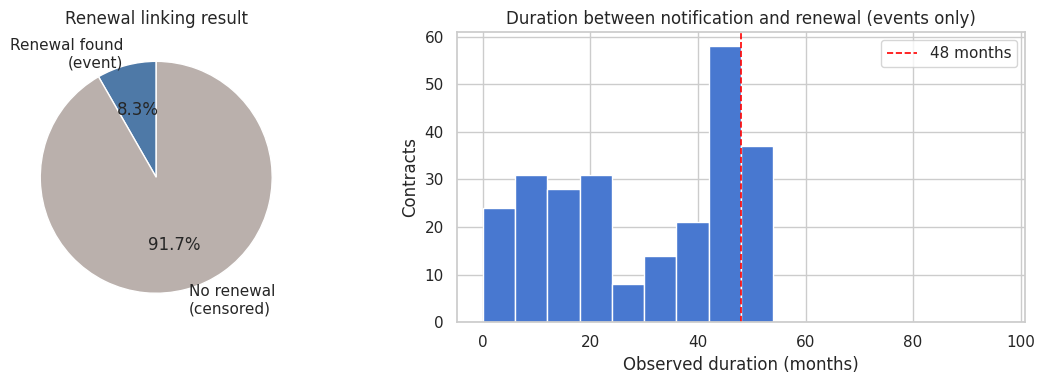

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: event vs censored pie
axes[0].pie([n_events, n_censored], labels=['Renewal found\n(event)', 'No renewal\n(censored)'],
            autopct='%1.1f%%', startangle=90, colors=['#4e79a7', '#bab0ac'])
axes[0].set_title('Renewal linking result')

# Right: distribution of observed durations for events
obs_events_trim = obs_events[obs_events <= 96]
axes[1].hist(obs_events_trim, bins=range(0, 97, 6), edgecolor='white')
axes[1].axvline(48, color='red', linestyle='--', linewidth=1.2, label='48 months')
axes[1].set_xlabel('Observed duration (months)')
axes[1].set_ylabel('Contracts')
axes[1].set_title('Duration between notification and renewal (events only)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Show a few example links
sample_links = links[~links['is_censored']][[
    'uid', 'renewal_uid', 'source_date_notification',
    'declared_duration_months', 'observed_duration_months', 'text_similarity'
]].head(5)

sample_links.rename(columns={
    'uid': 'Contract A',
    'renewal_uid': 'Contract B (renewal)',
    'source_date_notification': 'A notified',
    'declared_duration_months': 'Declared dur. (m)',
    'observed_duration_months': 'Observed dur. (m)',
    'text_similarity': 'Object similarity'
})

,Contract A,Contract B (renewal),A notified,Declared dur. (m),Observed dur. (m),Object similarity
0,214401622000112018v-XOnDSodM00,214401622000112022h0JYa7inW200,2018-03-14,48.0,48.49,0.824
1,214401622000112019MqNgfeQtj300,214401622000112023NXt3Q2OHpC00,2019-03-13,48.0,48.26,0.778
2,214401622000112019TLnx5fkSai00,214401622000112023NXt3Q2OHpC00,2019-03-28,48.0,47.77,1.000
3,214401622000112019_MMeN7kSxq00,214401622000112023MO2IpRdiwf00,2019-04-01,48.0,47.83,0.684
4,214401622000112019QX8fhqF8LM00,214401622000112023MO2IpRdiwf00,2019-04-04,48.0,47.73,1.000


> **Linking rate is 8.3%** — this is a baseline. The guide targets 40–60% after Week 3 improvements (stricter CPV matching, one-to-one constraint, manual precision/recall evaluation).

---
## 6 — Source Comparison: Which Source is Better for What?

Both sources are used because they complement each other. The table below summarises the recommendation per field.

In [ ]:
comp = pd.read_csv(PROCESSED / 'source_comparison.csv')
comp

,Field,BOAMP availability,BOAMP completion %,DECP availability,DECP completion %,Recommended source,Justification
0,Buyer SIRET,Partial,8.0,Yes,100.0,DECP,Mandatory 14-digit SIRET in DECP; in BOAMP only eForms notices (2024+) carry...
1,Buyer name,Yes,100.0,Yes,100.0,Both,"BOAMP has the declared name (free text, variants); the tabular DECP adds a S..."
2,Contract object (text),Yes,100.0,Yes,99.9,BOAMP,"Longer, richer text in BOAMP (NLP input for Phase 2); DECP object is terse."
3,CPV code,Yes,97.8,Yes,100.0,Both,Well filled in both; cross-check to fix generic division-level codes.
4,Amount (EUR),Partial,44.6,Yes,95.6,DECP,Mandatory in DECP; in BOAMP mostly on award notices only and format-dependent.
5,Contract duration,Partial,34.4,Yes,99.4,DECP,dureeMois is a mandatory DECP field; BOAMP declares it on ~3/4 of contract n...
6,Notification date,No,—,Yes,100.0,DECP,Only DECP has the actual notification date — the survival-analysis time origin.
7,Publication date,Yes,100.0,Yes,98.0,BOAMP,BOAMP dateparution is universal and reliable; DECP publication date can lag ...
8,Award date,Partial,41.8,No,—,BOAMP,Award notices carry DATE_ATTRIBUTION (95%); absent from DECP.
9,Winner identity,Partial,37.0,Yes,95.5,Both,"BOAMP gives the name, DECP the SIRET; complementary."


In [ ]:
# Visual summary: field completeness side-by-side
comp_num = comp[comp['boamp_completion_pct'].notna() & comp['decp_completion_pct'].notna()].copy()

x = range(len(comp_num))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - w/2 for i in x], comp_num['boamp_completion_pct'], w, label='BOAMP', color='#4e79a7')
ax.bar([i + w/2 for i in x], comp_num['decp_completion_pct'],  w, label='DECP',  color='#f28e2b')
ax.set_xticks(list(x))
ax.set_xticklabels(comp_num['field'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Fill rate (%)')
ax.set_title('Field completeness: BOAMP vs DECP')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

KeyError: 'boamp_completion_pct'

---
## Summary

| What | Where | Why |
|------|-------|-----|
| Raw contract announcements + rich text | **BOAMP** JSON | Full 2015–2024 coverage, event structure, NLP input |
| Signed contracts with amounts and dates | **DECP** Parquet | SIRET, notification date, amounts — needed for survival time origin |
| Working corpus (filtered, flat, clean) | `boamp_clean.csv` / `decp_clean.csv` | Scope-filtered, fields flagged, durations validated, taxonomy tagged |
| Survival target variable | `decp_renewal_links.csv` | Event/censoring status + observed duration per contract |

**Next steps (Phases 2–4):**
1. **NLP classification** — fine-tune the taxonomy using CamemBERT / TF-IDF on the `objet` field (Weeks 4–5)
2. **Survival modeling** — Kaplan-Meier + Cox + Weibull on `decp_clean` joined to `decp_renewal_links` (Weeks 6–8)
3. **Trend / change-point detection** — time series by category using PELT / HMM (Weeks 9–10)